可用的中文字体: ['Songti SC', 'STHeiti', 'PingFang HK', 'STHeiti', 'Heiti TC', 'STFangsong', 'Noto Sans Kaithi', 'Kai', 'LiHei Pro', 'LiSong Pro', 'BiauKai', 'Kailasa', 'Hei', 'Yuanti SC', 'Heiti TC', 'Kaiti SC']
成功读取文件，形状: (2916, 7)
可用列名: ['原始行号', '说话人', '文本内容', 'source', 'BERTopic主题ID_Erlangshen', '事件ID_Hybrid_V5', '是否为新事件开始_Hybrid_V5']
开始合并相邻相同说话人的台词...
合并后的行数: 1188 (原始行数: 2916)

各角色台词数量（合并后）:
说话人
许野     375
陈青青    171
江美琳     97
顾梦瑶     76
陈寒松     76
张虹      55
江薇      54
刘倩      43
许向东     40
秦志伟     33
Name: count, dtype: int64

各角色台词总长度:
说话人
许野     8894
江美琳    2457
陈青青    2229
陈寒松    2042
顾梦瑶    2034
刘倩     1043
江薇     1004
npc     910
张虹      820
秦志伟     740
Name: 文本内容, dtype: int64

主要角色: ['许野', '陈青青', '江美琳', '顾梦瑶', '陈寒松']
成功加载 749 个停用词

分析每个主要角色的高频词...

许野 的高频词:
青青: 46
阿姨: 31
现在: 25
女朋友: 20
知道: 19
不是: 18
一起: 17
叔叔: 13
我要: 11
爸妈: 11

陈青青 的高频词:
知道: 14
许野: 14
没有: 9
答应: 7
胡说: 7
是不是: 6
男朋友: 5
不是: 5
笨猪: 5
今天: 5

江美琳 的高频词:
青青: 35
小许: 25
妈妈: 12
一起: 9
许野: 8
知道: 8
优秀: 6
回来: 6
吃饭: 6
现在: 5

顾梦瑶

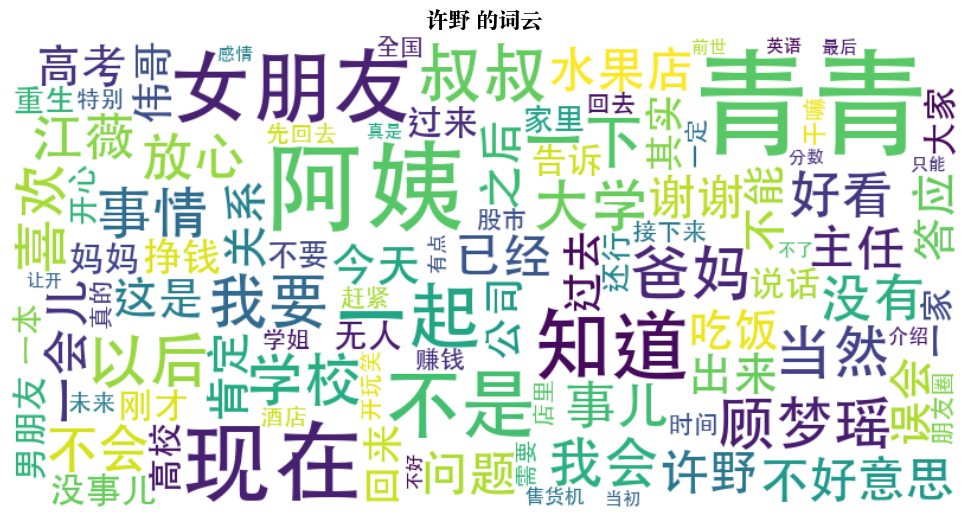

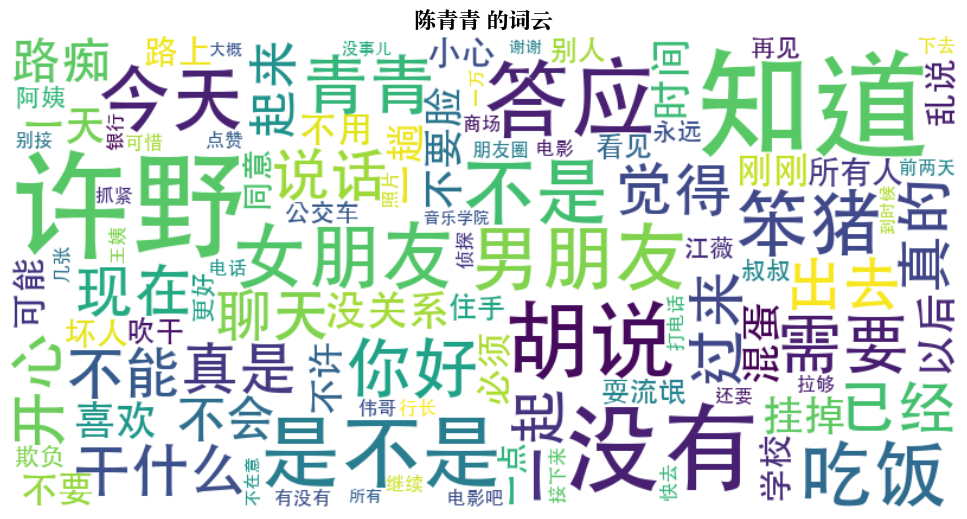

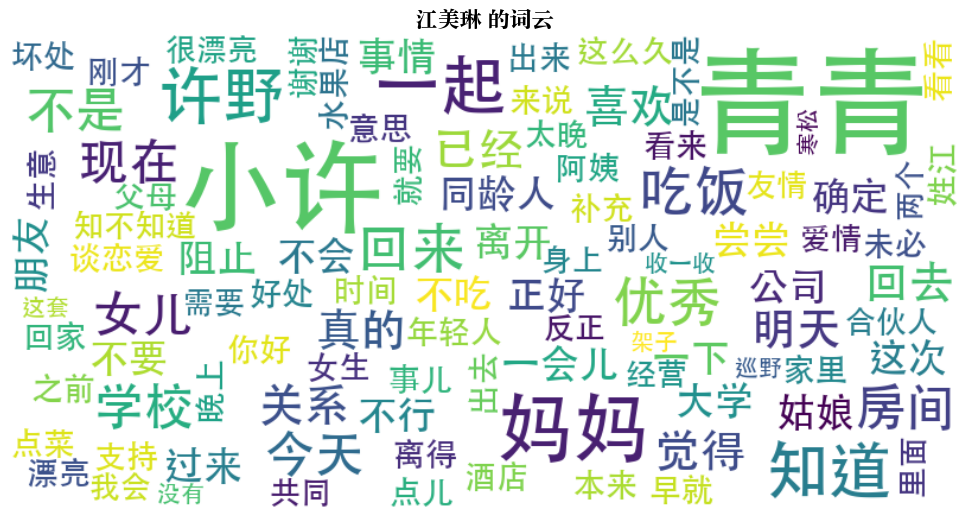

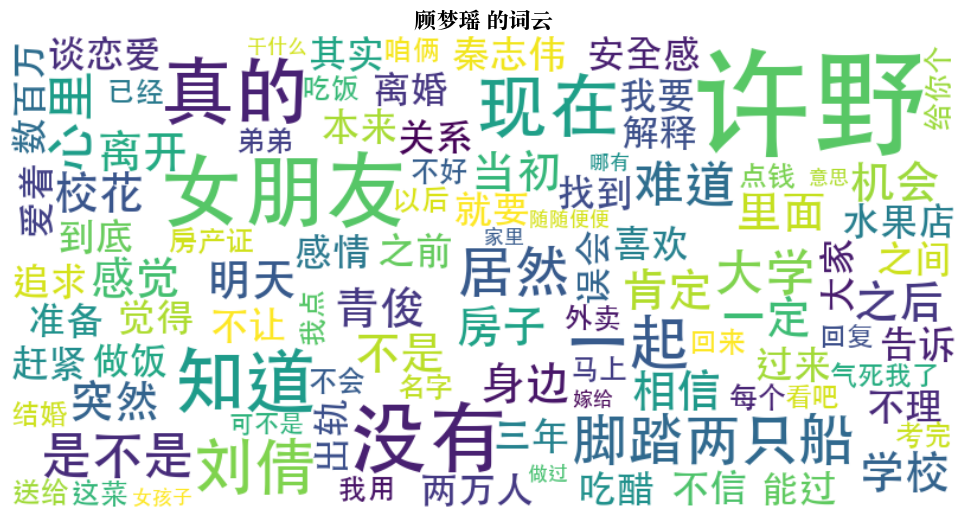

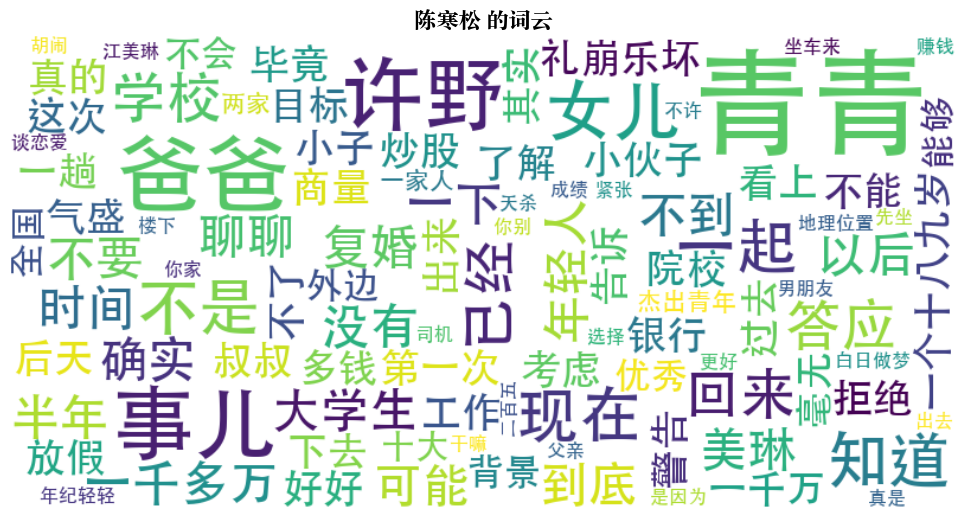

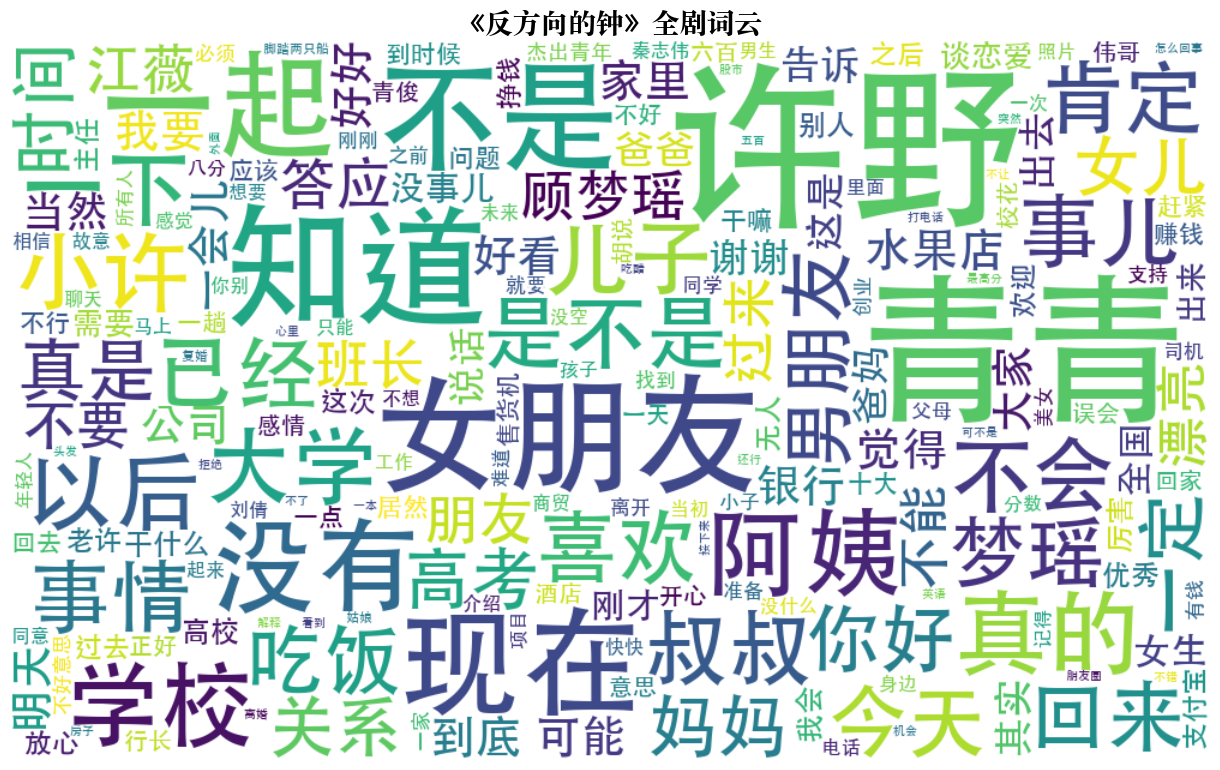

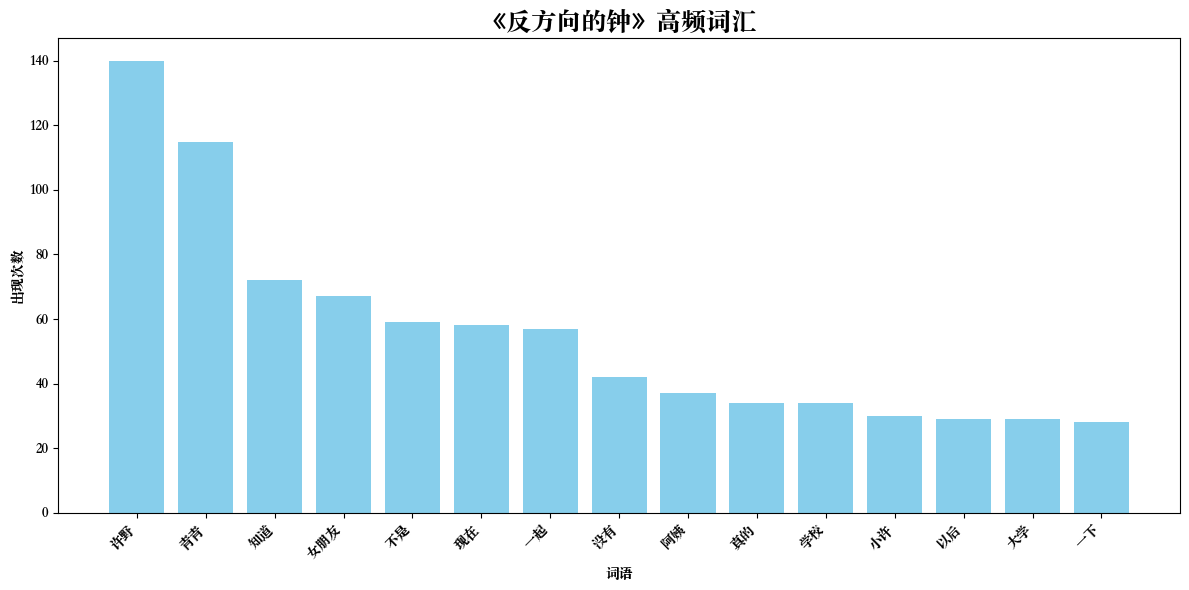

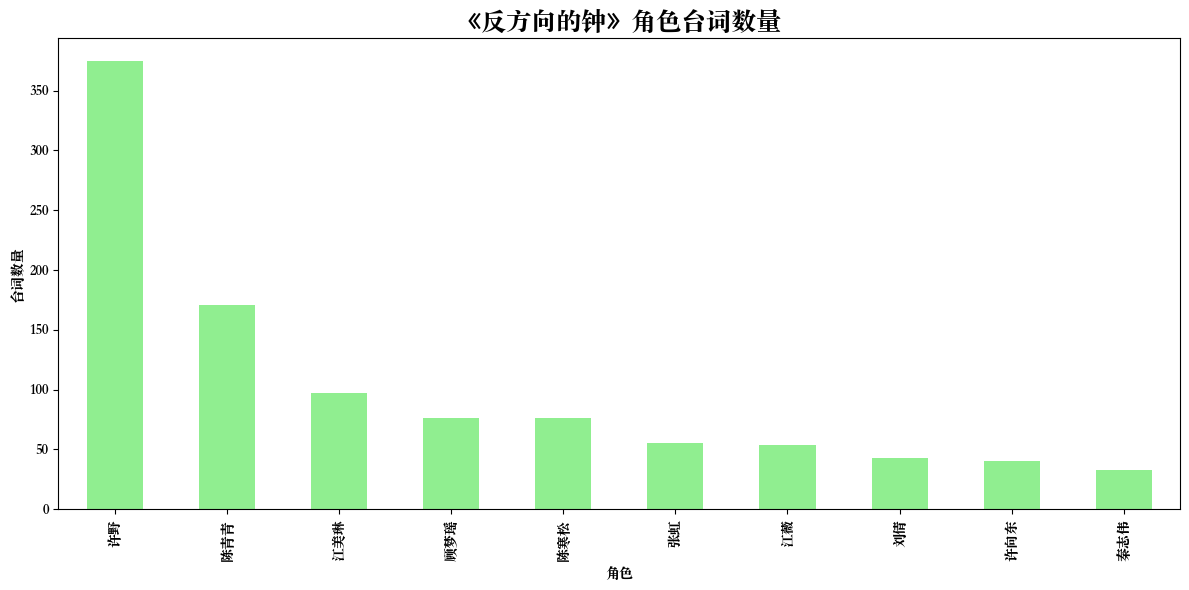

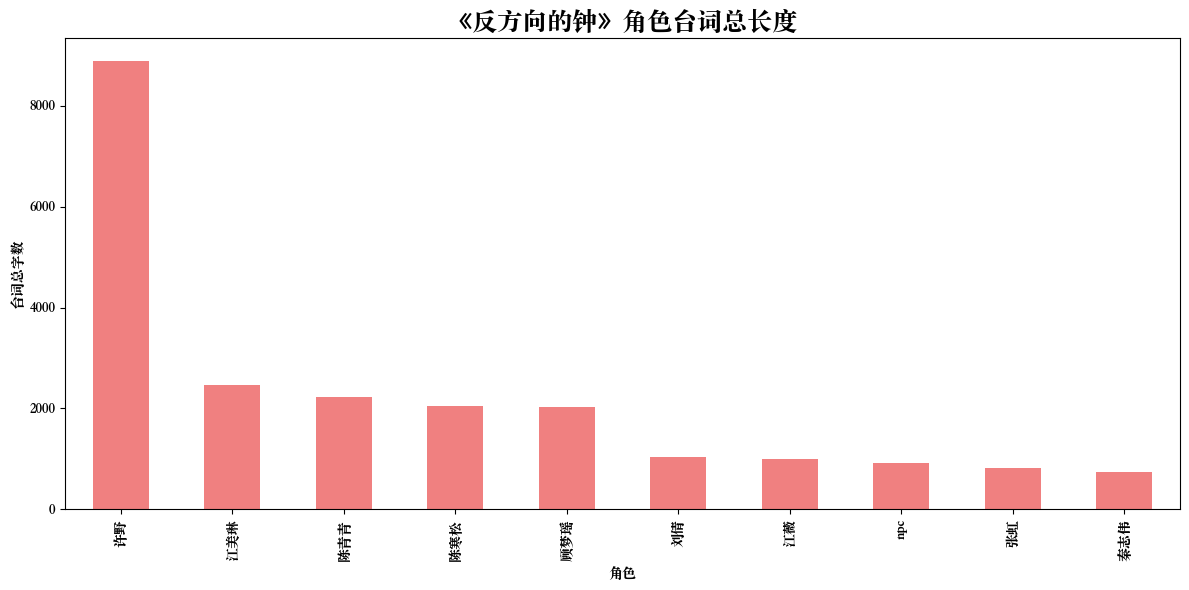

In [3]:
import pandas as pd
import numpy as np
import jieba
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 检查系统中可用的中文字体
def find_chinese_fonts():
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    chinese_fonts = [f for f in available_fonts if any(c in f for c in 
                   ['Heiti', 'Hei', 'Ming', 'Song', 'Yuan', 'Kai', 'Fang', 
                    'PingFang', '黑体', '宋体', '楷体', '仿宋', '圆体'])]
    print("可用的中文字体:", chinese_fonts)
    return chinese_fonts

# 获取系统中可用的中文字体
chinese_fonts = find_chinese_fonts()

# 设置默认的字体路径 - 这里我们使用STHeiti，因为在您的代码中它似乎可用
font_path = '/System/Library/Fonts/STHeiti Medium.ttc'

# 配置matplotlib的字体设置
plt.rcParams['font.family'] = 'sans-serif'
if chinese_fonts:
    plt.rcParams['font.sans-serif'] = chinese_fonts + ['DejaVu Sans']  # 添加备用字体
else:
    # 直接用路径方式设置字体
    custom_font = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = custom_font.get_name()

plt.rcParams['axes.unicode_minus'] = False  # 避免负号显示为方块

# 读取CSV文件
file_path = '/Users/sean/Desktop/短剧项目/反方向的钟_hybrid_v5_events.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8')
    print("成功读取文件，形状:", df.shape)
except Exception as e:
    print(f"读取文件错误: {e}")
    # 如果出错，可以尝试不同的编码
    try:
        df = pd.read_csv(file_path, encoding='gbk')
        print("使用GBK编码成功读取")
    except:
        print("尝试不同编码仍然失败")
        raise

# 查看列名并确认列名
print("可用列名:", df.columns.tolist())

# 确保必要的列存在
speaker_column = '说话人'
text_column = '文本内容'

if speaker_column not in df.columns or text_column not in df.columns:
    print(f"警告: 找不到必要的列 '{speaker_column}' 或 '{text_column}'")
    speaker_column = df.columns[1]  # 默认使用第二列作为说话人
    text_column = df.columns[2]     # 默认使用第三列作为文本内容
    print(f"使用 '{speaker_column}' 作为说话人列，'{text_column}' 作为文本内容列")

# 合并相邻相同说话人的台词
print("开始合并相邻相同说话人的台词...")
merged_df = []
current_speaker = None
current_text = ""

for i, row in df.iterrows():
    speaker = row[speaker_column]
    text = row[text_column]
    
    # 如果是同一个说话人，合并台词
    if speaker == current_speaker:
        current_text += " " + str(text)
    else:
        # 保存上一个说话人的台词(跳过首行初始化)
        if current_speaker is not None:
            merged_df.append({
                speaker_column: current_speaker,
                text_column: current_text,
                '合并行数': 1
            })
        
        # 更新当前说话人和台词
        current_speaker = speaker
        current_text = str(text)

# 添加最后一个说话人的台词
if current_speaker is not None:
    merged_df.append({
        speaker_column: current_speaker,
        text_column: current_text,
        '合并行数': 1
    })

# 转换为DataFrame
merged_df = pd.DataFrame(merged_df)
print(f"合并后的行数: {len(merged_df)} (原始行数: {len(df)})")

# 统计每个角色的台词数量
speaker_counts = merged_df[speaker_column].value_counts()
print("\n各角色台词数量（合并后）:")
print(speaker_counts.head(10))

# 计算每个角色的总台词长度
speaker_text_lengths = merged_df.groupby(speaker_column)[text_column].apply(lambda x: sum(len(str(text)) for text in x))
print("\n各角色台词总长度:")
print(speaker_text_lengths.sort_values(ascending=False).head(10))

# 提取主要角色（假设台词数量最多的前5个）
main_characters = speaker_counts.head(5).index.tolist()
print(f"\n主要角色: {main_characters}")

# 加载停用词
def load_stopwords(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            stopwords = set(line.strip() for line in f if line.strip())
        print(f"成功加载 {len(stopwords)} 个停用词")
        return stopwords
    except Exception as e:
        print(f"加载停用词失败: {e}")
        # 返回一个基本的停用词集合作为备用
        basic_stopwords = set(['的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', '自己', '这'])
        print("使用基本停用词集合")
        return basic_stopwords

# 加载停用词
stopwords_path = '/Users/sean/Desktop/短剧项目/hit_stopwords.txt'
stopwords = load_stopwords(stopwords_path)

# 分析每个主要角色的高频词
print("\n分析每个主要角色的高频词...")
character_word_freq = {}

for character in main_characters:
    # 获取该角色的所有台词
    character_texts = merged_df[merged_df[speaker_column] == character][text_column]
    
    # 合并该角色的所有台词
    character_text = ' '.join(character_texts.astype(str))
    
    # 分词
    words = jieba.lcut(character_text)
    
    # 去除停用词和单个字符
    filtered_words = [w for w in words if w not in stopwords and len(w) > 1]
    
    # 统计词频
    word_freq = Counter(filtered_words)
    
    # 保存结果
    character_word_freq[character] = word_freq
    
    # 打印结果
    print(f"\n{character} 的高频词:")
    for word, count in word_freq.most_common(10):
        print(f"{word}: {count}")

# 为每个主要角色生成词云
print("\n为每个主要角色生成词云...")
for character in main_characters:
    try:
        word_freq = character_word_freq[character]
        
        # 如果词频为空，跳过
        if not word_freq:
            print(f"跳过 {character} 的词云生成（没有足够的词语）")
            continue
        
        # 生成词云
        wc = WordCloud(
            font_path=font_path,
            width=800,
            height=400,
            background_color='white',
            max_words=100,
            max_font_size=100,
            min_font_size=10,
            random_state=42
        ).generate_from_frequencies(word_freq)
        
        # 显示词云
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"{character} 的词云", fontsize=16)
        plt.tight_layout(pad=0)
        
        # 保存词云图像
        save_path = f'/Users/sean/Desktop/短剧项目/词云_{character}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"{character} 的词云已保存至: {save_path}")
        
    except Exception as e:
        print(f"生成 {character} 的词云时出错: {e}")

# 全剧词云分析
print("\n生成全剧词云...")

# 合并所有文本
all_text = ' '.join(merged_df[text_column].astype(str))

# 分词
all_words = jieba.lcut(all_text)

# 去除停用词和单个字符
filtered_all_words = [w for w in all_words if w not in stopwords and len(w) > 1]

# 统计词频
all_word_freq = Counter(filtered_all_words)

# 显示前20个高频词
print("\n全剧高频词:")
for word, count in all_word_freq.most_common(20):
    print(f"{word}: {count}")

# 生成词云
try:
    all_wc = WordCloud(
        font_path=font_path,
        width=1000,
        height=600,
        background_color='white',
        max_words=200,
        max_font_size=150,
        min_font_size=10,
        random_state=42,
        contour_width=1,
        contour_color='steelblue'
    ).generate_from_frequencies(all_word_freq)
    
    # 显示词云
    plt.figure(figsize=(12, 8))
    plt.imshow(all_wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("《反方向的钟》全剧词云", fontsize=20)
    plt.tight_layout(pad=0)
    
    # 保存词云图像
    save_path = '/Users/sean/Desktop/短剧项目/反方向的钟_全剧词云.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"全剧词云已保存至: {save_path}")
    
    # 绘制前15个高频词的条形图
    top_words = dict(all_word_freq.most_common(15))
    
    plt.figure(figsize=(12, 6))
    plt.bar(top_words.keys(), top_words.values(), color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title("《反方向的钟》高频词汇", fontsize=18)
    plt.xlabel("词语")
    plt.ylabel("出现次数")
    plt.tight_layout()
    
    # 保存条形图
    bar_path = '/Users/sean/Desktop/短剧项目/反方向的钟_高频词.png'
    plt.savefig(bar_path, dpi=300, bbox_inches='tight')
    print(f"高频词条形图已保存至: {bar_path}")
    
except Exception as e:
    print(f"生成全剧词云时出错: {e}")

# 角色对话分析
print("\n生成角色对话分析...")

# 绘制角色台词数量图
plt.figure(figsize=(12, 6))
speaker_counts.head(10).plot(kind='bar', color='lightgreen')
plt.title("《反方向的钟》角色台词数量", fontsize=18)
plt.xlabel("角色")
plt.ylabel("台词数量")
plt.tight_layout()

# 保存角色台词数量图
char_path = '/Users/sean/Desktop/短剧项目/反方向的钟_角色台词数量.png'
plt.savefig(char_path, dpi=300, bbox_inches='tight')
print(f"角色台词数量图已保存至: {char_path}")

# 绘制角色台词长度图
plt.figure(figsize=(12, 6))
speaker_text_lengths.sort_values(ascending=False).head(10).plot(kind='bar', color='lightcoral')
plt.title("《反方向的钟》角色台词总长度", fontsize=18)
plt.xlabel("角色")
plt.ylabel("台词总字数")
plt.tight_layout()

# 保存角色台词长度图
length_path = '/Users/sean/Desktop/短剧项目/反方向的钟_角色台词长度.png'
plt.savefig(length_path, dpi=300, bbox_inches='tight')
print(f"角色台词长度图已保存至: {length_path}")

# 将合并后的数据保存到CSV文件
try:
    merged_file_path = '/Users/sean/Desktop/短剧项目/反方向的钟_合并台词.csv'
    merged_df.to_csv(merged_file_path, index=False, encoding='utf-8')
    print(f"\n合并后的数据已保存至: {merged_file_path}")
except Exception as e:
    print(f"保存合并后的数据时出错: {e}")

print("\n分析完成！")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jieba

# 读取数据
df = pd.read_csv("/Users/sean/Desktop/短剧项目/反方向的钟_hybrid_v5_events.csv")
df = df.dropna(subset=["文本内容"])
# plt.rcParams['font.family'] = 'Arial Unicode MS'  # 更通用
# 添加字数与词数列
df["字数"] = df["文本内容"].apply(lambda x: len(x.replace(" ", "")))
df["词数"] = df["文本内容"].apply(lambda x: len(list(jieba.cut(x))))

# 设置样式
sns.set(style="whitegrid", font="Arial Unicode MS")  # 设置中文字体支持

# 可视化：字数直方图 + 密度曲线
plt.figure(figsize=(10, 5))
sns.histplot(df["字数"], kde=True, bins=20, color='skyblue')
plt.title("对话文本字数分布（含密度曲线）")
plt.xlabel("字数")
plt.ylabel("出现频次")
plt.show()

# 可视化：词数箱线图
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["词数"], color='lightcoral')
plt.title("对话文本词数的箱线图")
plt.ylabel("词数")
plt.show()
